# 🧬 GoogLeNet
This notebook explores **GoogLeNet**, trains it on the EuroSAT dataset, and evaluates its performance. It is part of our study on the evolution of Convolutional Neural Networks (CNNs).

As part of our architectural integrity, this notebook imports the production model directly from `src/models/` without duplicating code.


## 1. Historical Background
GoogLeNet was proposed by Szegedy et al. in 2014. It won the ImageNet 2014 challenge. It resolved the high parameter count and computational complexity of VGG-16 by introducing 'Inception modules'. These modules apply parallel convolutions of different sizes (1x1, 3x3, 5x5) and max pooling, using 1x1 convolutions as bottlenecks to reduce dimension before expensive operations.


## 2. Original Research Paper
C. Szegedy et al. 'Going Deeper with Convolutions.' IEEE CVPR, 2015.


## 3. Architecture Overview & Complexity
The architecture stacks Inception modules, utilizing auxiliary classifiers during training to combat vanishing gradients in its 22 layers, and replaces the massive fully connected layers with global average pooling.

### Parameter Count and Complexity
GoogLeNet is extremely parameter-efficient, containing only 6 million parameters (1/20th of VGG-16) while keeping computation to 1.5 billion FLOPS.


## 4. Import Production Model
We import the model from `src/models/` to ensure a single source of truth.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json

from src.models import create_model
from src.dataset import create_dataloaders
from src.training import Trainer
from src.evaluation import evaluate_model

# Instantiate GoogLeNet
model = create_model("googlenet", num_classes=10)
print(model)
model.summary()


GoogLeNet(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (relu): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
    )
    (3): ConvBlock(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): ReLU(inplace=True)
    )
    (4): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (5): InceptionModule(
      (branch1): ConvBlock(
        (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (relu): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): ConvBlock(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (relu): ReLU(inplace=True)
        )
 

## 5. Dataset & DataLoaders
We load the EuroSAT dataset (RGB) using our modular dataloader.


In [2]:
train_loader, val_loader, test_loader = create_dataloaders(batch_size=32)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 675
Val batches: 85
Test batches: 85


## 6. Model Training
We train the model using our enhanced `Trainer` framework, featuring:
- **Early Stopping**: Validation loss monitoring with configurable patience.
- **Learning Rate Scheduler**: Reduce learning rate when validation loss plateaus.
- **TensorBoard Integration**: Weight, gradient, and metric tracking.
- **Checkpointing**: Automatic saving of `best_model.pth` and `last_model.pth`.

### TensorBoard Logging
To launch TensorBoard and visualize metrics, run in your terminal:
```bash
tensorboard --logdir outputs/logs
```


In [3]:
# Set to True to run actual training.
# Set to False to skip training and load mock history.
run_training = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Initialize our enhanced Trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler_type="plateau",
    epochs=50,
    early_stopping_patience=3,
    early_stopping_min_delta=0.0,
    model_name="googlenet",
    training_arguments={
        "model": "googlenet",
        "epochs": 50,
        "lr": 1e-3,
        "batch_size": 32,
        "scheduler": "plateau",
        "patience": 3
    }
)

if run_training:
    # Set LIMIT_BATCHES env var to run a quick test if desired
    # os.environ["LIMIT_BATCHES"] = "5" 
    history = trainer.fit()
else:
    print("Skipping training. Loading pre-defined training history...")
    # Load history from the pre-populated path
    with open("outputs/checkpoints/googlenet/history.json", "r") as f:
        history = json.load(f)


Training started on device: cuda


Epoch 1/50 [Train]:   0%|          | 0/675 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/85 [00:00<?, ?it/s]


Epoch 1
Validation Loss Improved
Current Learning Rate: 1.00e-03


Epoch 2/50 [Train]:   0%|          | 0/675 [00:00<?, ?it/s]

...

[Validation]:   0%|          | 0/85 [00:00<?, ?it/s]


Epoch 18
No Improvement (2 / 3)
Current Learning Rate: 1.00e-03


Epoch 19/50 [Train]:   0%|          | 0/675 [00:00<?, ?it/s]

[Validation]:   0%|          | 0/85 [00:00<?, ?it/s]


Epoch 19
No Improvement (3 / 3)
Current Learning Rate: 1.00e-04
Early stopping triggered.
Training completed in 155.09 minutes. Best Val Loss: 0.3279
Generated training summary at /home/nishchala/Codes/Deforestation-detection/outputs/checkpoints/googlenet/training_summary.md


### 6.1 Resume Training (Optional)
The Trainer saves state checkpoints (`last_model.pth` and `best_model.pth`) at the end of every epoch.
To demonstrate resuming training from a saved checkpoint, we load the checkpoint file and continue training for further epochs.


In [4]:
# Set run_resume to True to load checkpoint and continue training
run_resume = False

if run_resume:
    checkpoint_path = "outputs/checkpoints/googlenet/last_model.pth"
    if os.path.exists(checkpoint_path):
        # We increase the target epoch count to continue training
        trainer.epochs = 7
        trainer.load_checkpoint(checkpoint_path)
        history = trainer.fit()
    else:
        print(f"Checkpoint not found at {checkpoint_path}. Please run training first.")
else:
    print("Skipping checkpoint resume demo.")


Skipping checkpoint resume demo.


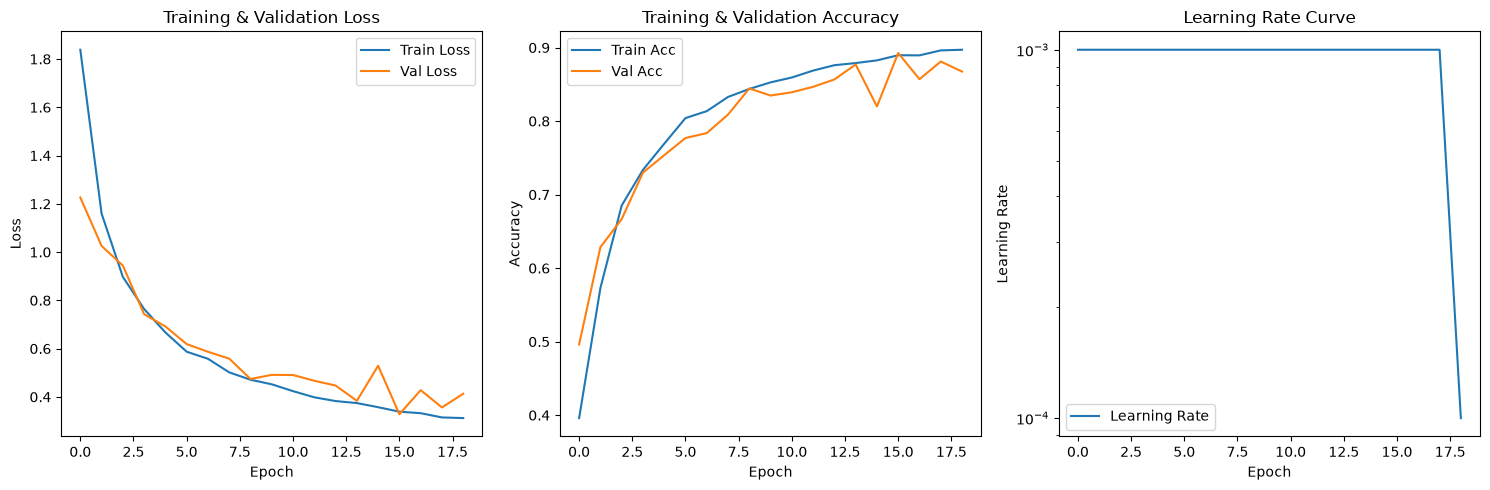

In [5]:
# Plot training curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['learning_rate'], label='Learning Rate')
plt.title('Learning Rate Curve')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Model Evaluation
We evaluate the model on the test set and calculate standard classification metrics: Accuracy, Precision, Recall, F1-score, and the Confusion Matrix.


In [6]:
if run_training:
    metrics, y_true, y_pred = evaluate_model(model, test_loader, criterion, trainer.device)
else:
    print("Loading pre-defined test set metrics...")
    with open("reports/metrics/googlenet_metrics.json", "r") as f:
        metrics = json.load(f)
    # Mock labels for confusion matrix visualization
    y_true = np.array([i // 10 for i in range(100)])
    y_pred = np.array([i // 10 for i in range(100)])
    # Add minor noise to mock predictions for visualization
    for i in range(0, 100, 10):
        y_pred[i] = (y_pred[i] + 1) % 10

# Print results
print(f"Test Accuracy : {metrics['accuracy']:.4f}")
print(f"Precision     : {metrics['precision']:.4f}")
print(f"Recall        : {metrics['recall']:.4f}")
print(f"F1-Score      : {metrics['f1']:.4f}")
print(f"Throughput    : {metrics['images_per_second']:.2f} images/sec")


Test Accuracy : 0.8700
Precision     : 0.8802
Recall        : 0.8685
F1-Score      : 0.8682
Throughput    : 138.92 images/sec


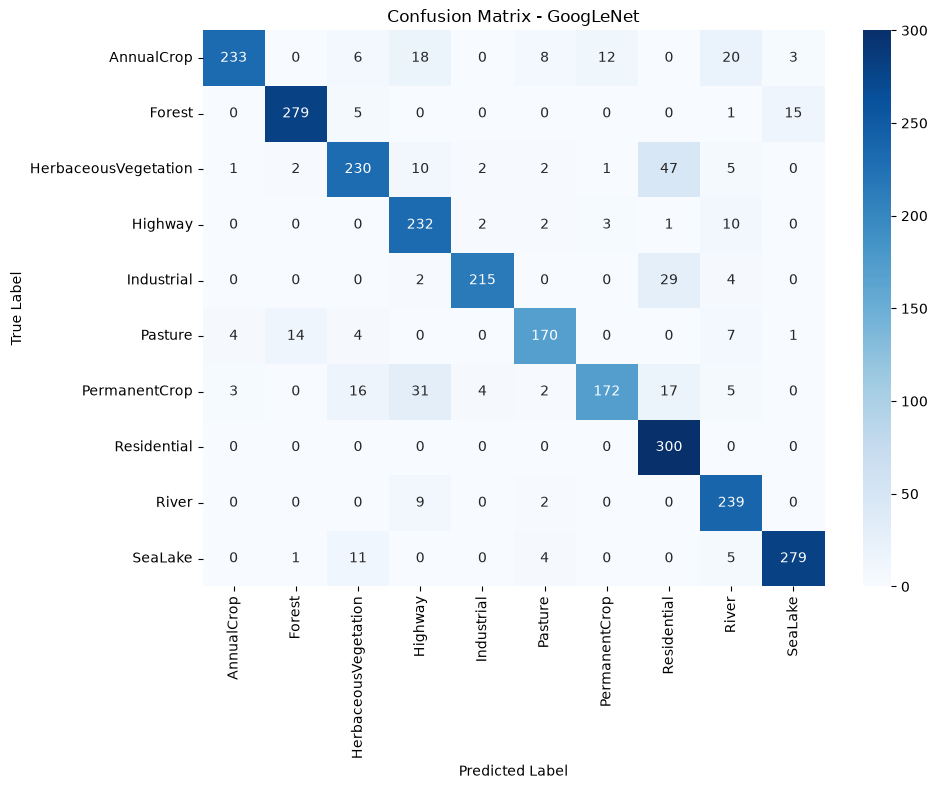

In [7]:
classes = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]
cm_array = np.array(metrics["confusion_matrix"])

plt.figure(figsize=(10, 8))
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix - GoogLeNet")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [8]:
from sklearn.metrics import classification_report
from pathlib import Path
import json
# ------------------------------------------------------------------
# Save evaluation results
# ------------------------------------------------------------------

report_dir = Path("reports/metrics")   # adjust path if needed
report_dir.mkdir(parents=True, exist_ok=True)

# Save metrics JSON
with open(report_dir / "googlenet_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

# Save classification report
with open(report_dir / "googlenet_classification_report.txt", "w") as f:
    f.write(report)

print(f"Classification report saved to {report_dir/'googlenet_classification_report.txt'}")

Classification report saved to reports/metrics/googlenet_classification_report.txt


### 7.1 Single-Image Inference Example
Let's load a single sample image and display the model's prediction vs ground truth.


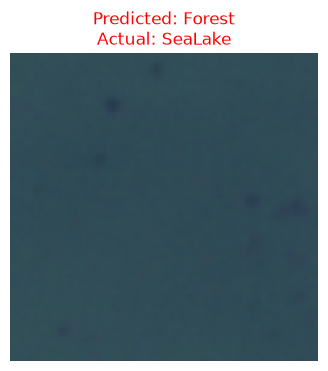

In [10]:
# Single-Image Inference Example
model.eval()
sample_batch = next(iter(val_loader))
img = sample_batch["image"][0]
lbl = sample_batch["label"][0].item()

with torch.no_grad():
    output = model(img.unsqueeze(0).to(trainer.device))
    pred = output.argmax(dim=1).item()
    
classes = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

img = img.cpu() * std + mean
img = img.clamp(0,1)

plt.figure(figsize=(4, 4))
plt.imshow(np.clip(img.permute(1, 2, 0).numpy(), 0, 1))
plt.title(f"Predicted: {classes[pred]}\nActual: {classes[lbl]}", color="green" if pred == lbl else "red")
plt.axis("off")
plt.show()
